# PSF Quality ML Analysis

This notebook applies machine learning techniques to determine which shapelet coefficients
distinguish **GOOD** PSFs from **MODERATE**, **BAD**, and **HORRIBLE** ones.

Sections:
1. Data Loading & EDA
2. Dimensionality Reduction — PCA vs. Manifold Learning (LLE, IsoMap) *(adapted from astroML Ch. 7)*
3. SVM Classification with completeness/contamination curves *(adapted from astroML Ch. 9)*
4. ROC Curves & Multi-Classifier Comparison *(adapted from astroML Ch. 9)*
5. Feature Importance

## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.manifold import LocallyLinearEmbedding, Isomap
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

In [2]:
DATA_DIR = Path('../output')

# Quality classes in decreasing order of PSF quality
QUALITY_ORDER  = ['GOOD', 'MODERATE', 'BAD', 'HORRIBLE']
QUALITY_COLORS = {'GOOD': '#2ecc71', 'MODERATE': '#f39c12',
                  'BAD': '#e74c3c',  'HORRIBLE': '#8e44ad'}

dfs = {}
for q in QUALITY_ORDER:
    df = pd.read_csv(DATA_DIR / f'{q}.csv', index_col=0)
    df['quality'] = q
    dfs[q] = df

data = pd.concat(dfs.values(), ignore_index=True)

shapelet_cols = [c for c in data.columns if c.startswith('sh_')]

print(f"Total samples : {len(data)}")
print(f"Shapelet features : {len(shapelet_cols)}")
print()
print(data['quality'].value_counts().reindex(QUALITY_ORDER))

Total samples : 420
Shapelet features : 28

quality
GOOD        105
MODERATE    105
BAD         105
HORRIBLE    105
Name: count, dtype: int64


In [3]:
# Build feature matrices
X_raw  = data[shapelet_cols].values          # (N, 28) raw shapelet coefficients
scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)         # standardised — required by many algorithms

y_labels = data['quality'].values            # string labels

# Multi-class integer labels (GOOD=0 … HORRIBLE=3)
q2i   = {q: i for i, q in enumerate(QUALITY_ORDER)}
y_multi = np.array([q2i[q] for q in y_labels])

# Binary labels: GOOD=1, everything else=0  ("is this a good PSF?")
y_bin   = (y_labels == 'GOOD').astype(int)

# 75 / 25 stratified split (used in sections 3–5)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(sss.split(X, y_bin))
X_tr,  X_te  = X[train_idx],       X[test_idx]
yb_tr, yb_te = y_bin[train_idx],   y_bin[test_idx]
ym_tr, ym_te = y_multi[train_idx], y_multi[test_idx]

print(f"Train: {len(X_tr)}  |  Test: {len(X_te)}")
print(f"Binary balance — train GOOD: {yb_tr.mean():.1%}  test GOOD: {yb_te.mean():.1%}")

Train: 315  |  Test: 105
Binary balance — train GOOD: 25.1%  test GOOD: 24.8%


## 2. Exploratory Data Analysis

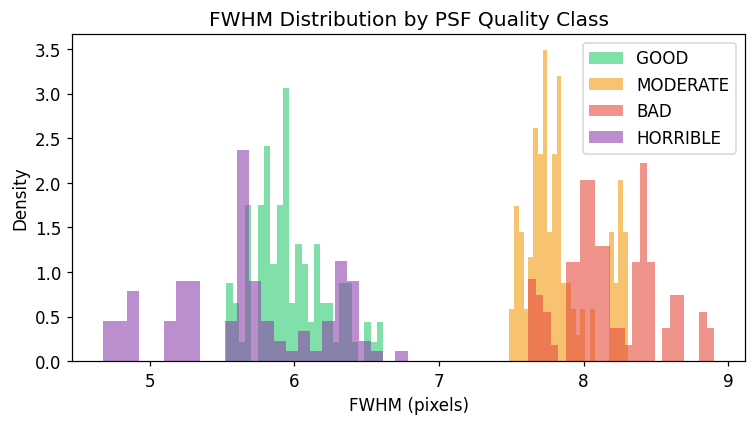

In [4]:
# FWHM distributions — quick sanity check that the class labels map to real PSF quality
fig, ax = plt.subplots(figsize=(7, 4))
for q in QUALITY_ORDER:
    vals = data.loc[data['quality'] == q, 'fwhm']
    ax.hist(vals, bins=25, alpha=0.6, color=QUALITY_COLORS[q], label=q, density=True)
ax.set_xlabel('FWHM (pixels)')
ax.set_ylabel('Density')
ax.set_title('FWHM Distribution by PSF Quality Class')
ax.legend()
plt.tight_layout()
plt.show()

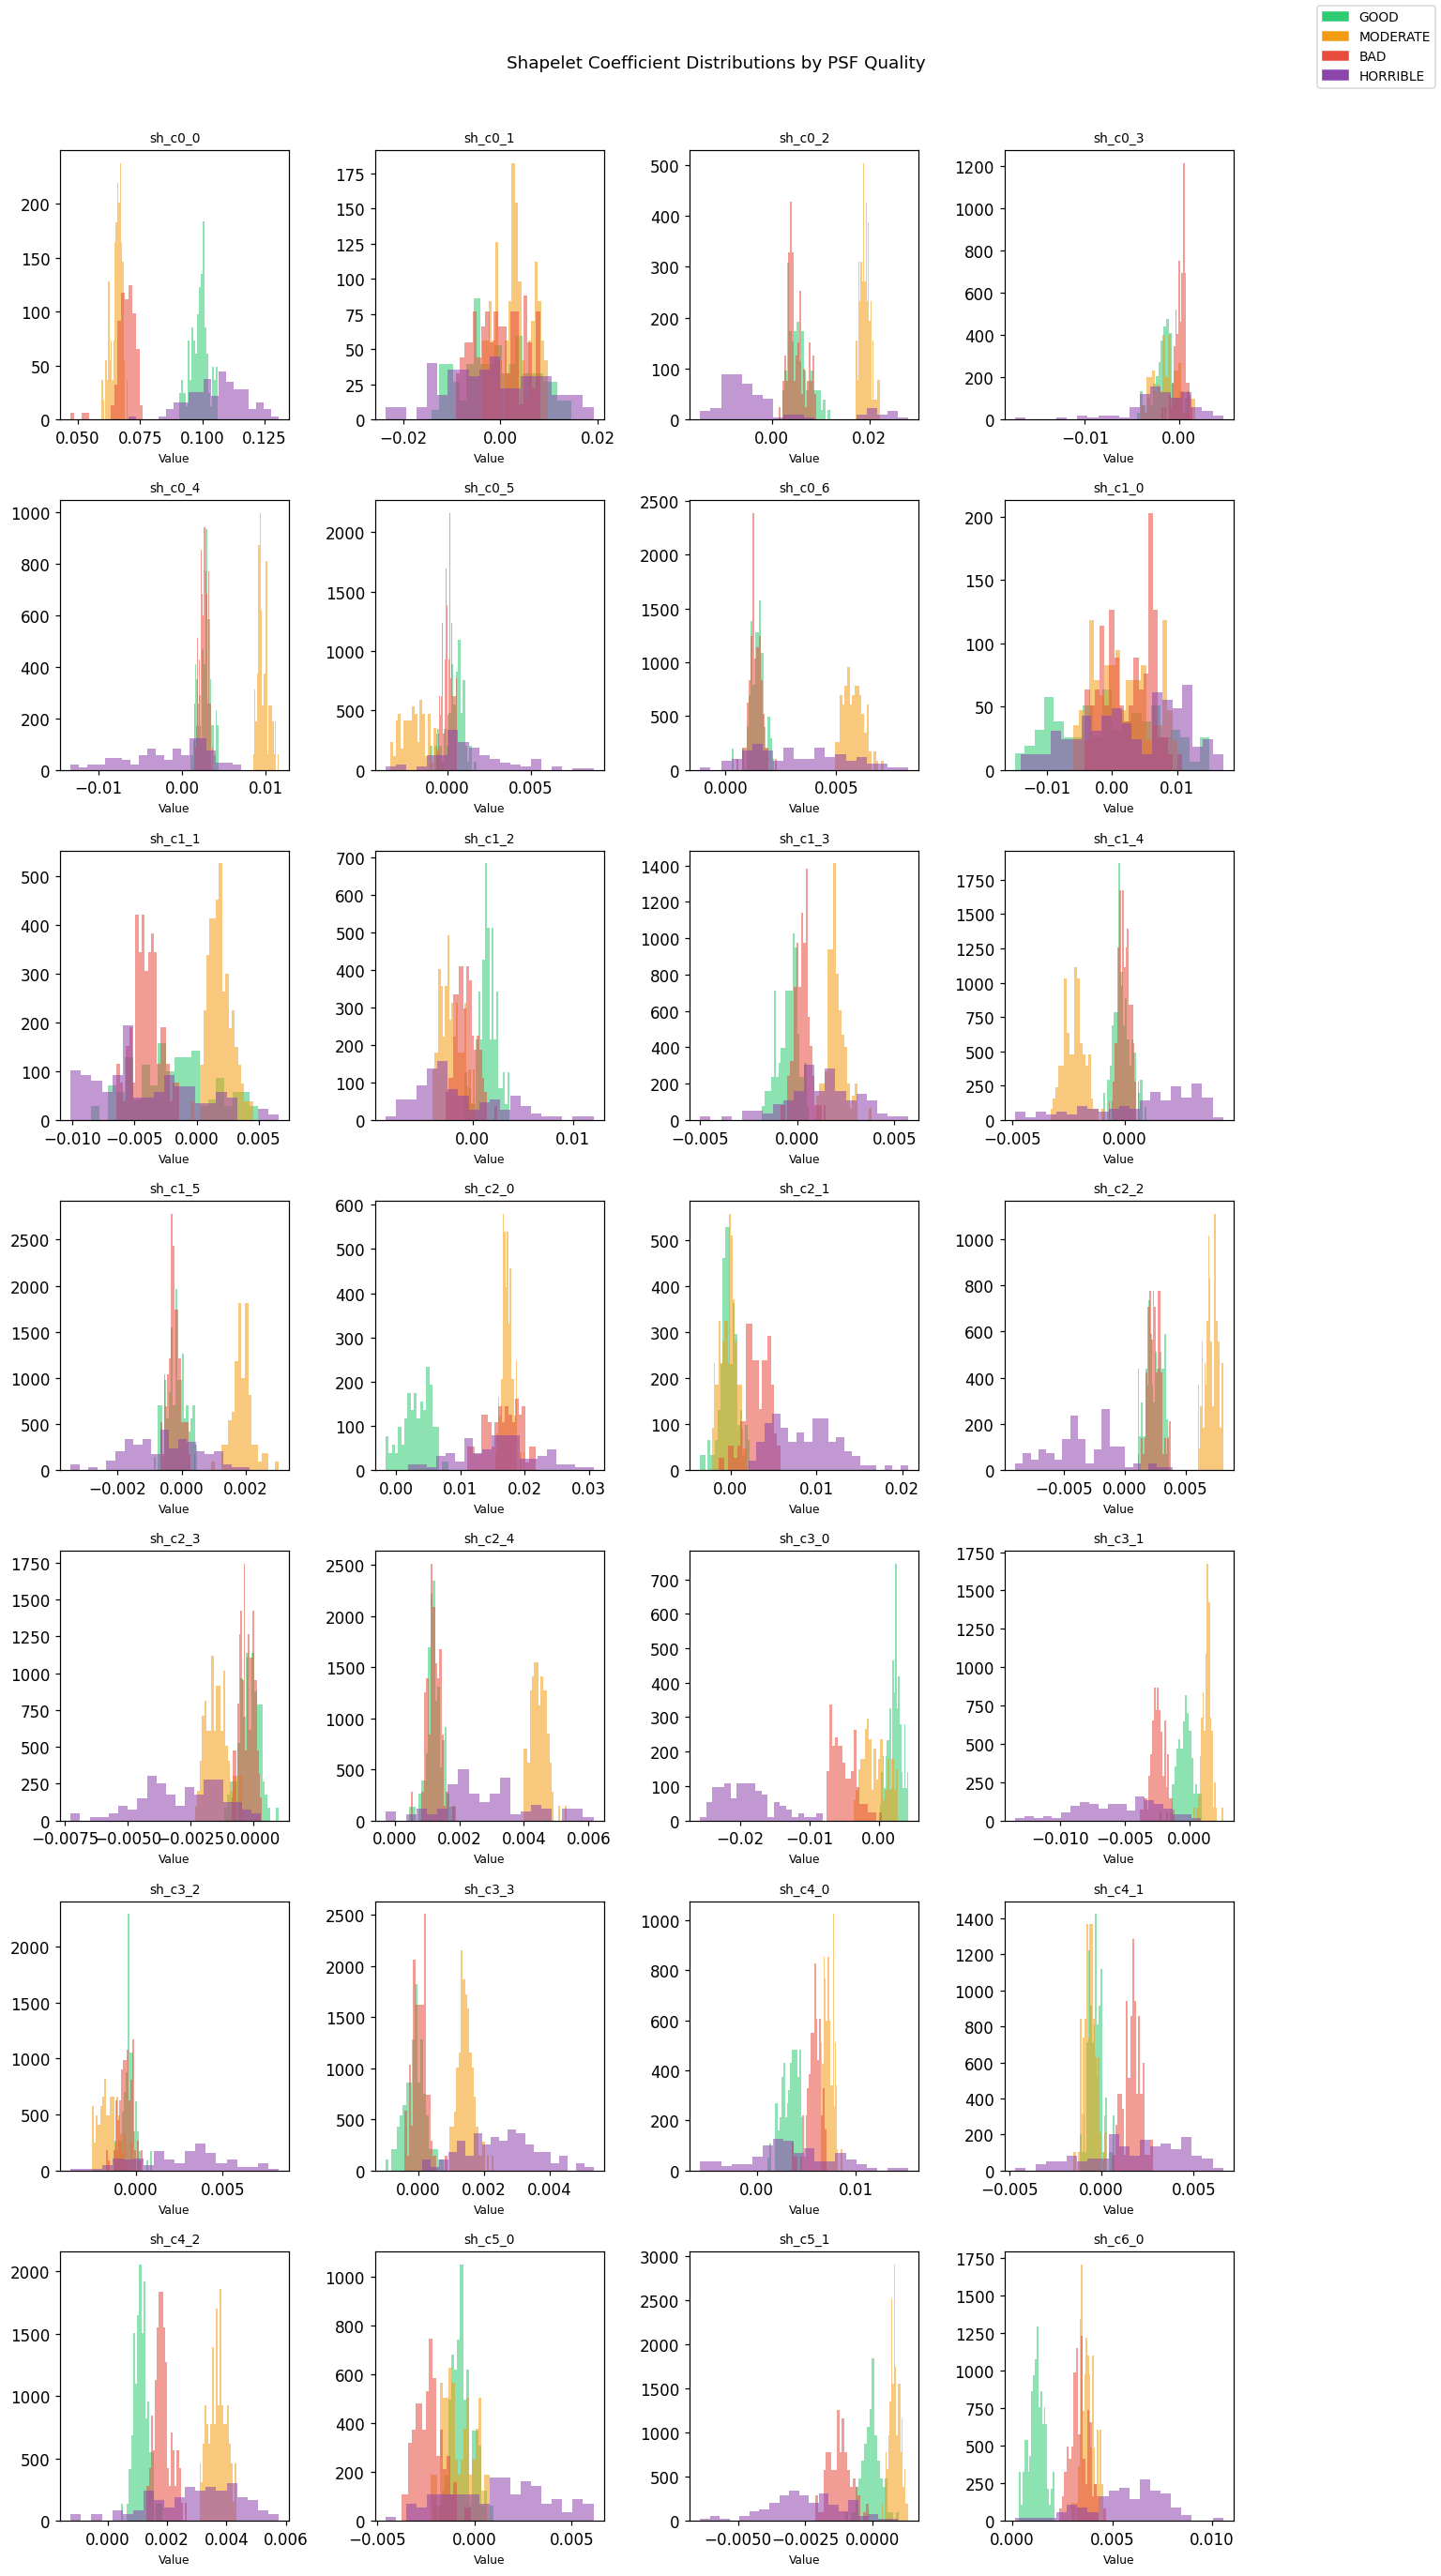

In [ ]:
# Distributions of the shapelet coefficients
fig, axes = plt.subplots(7, 4, figsize=(14, 25), sharey=False)
for ax, col in zip(axes.ravel(), shapelet_cols[:28]):
    for q in QUALITY_ORDER:
        vals = data.loc[data['quality'] == q, col]
        ax.hist(vals, bins=20, alpha=0.55, color=QUALITY_COLORS[q], label=q, density=True)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Value', fontsize=8)
handles = [mpatches.Patch(color=QUALITY_COLORS[q], label=q) for q in QUALITY_ORDER]
fig.legend(handles=handles, loc='upper right', fontsize=9)
plt.suptitle('Shapelet Coefficient Distributions by PSF Quality', fontsize=12)
plt.tight_layout(rect=[0, 0, .88, 0.97])
plt.show()

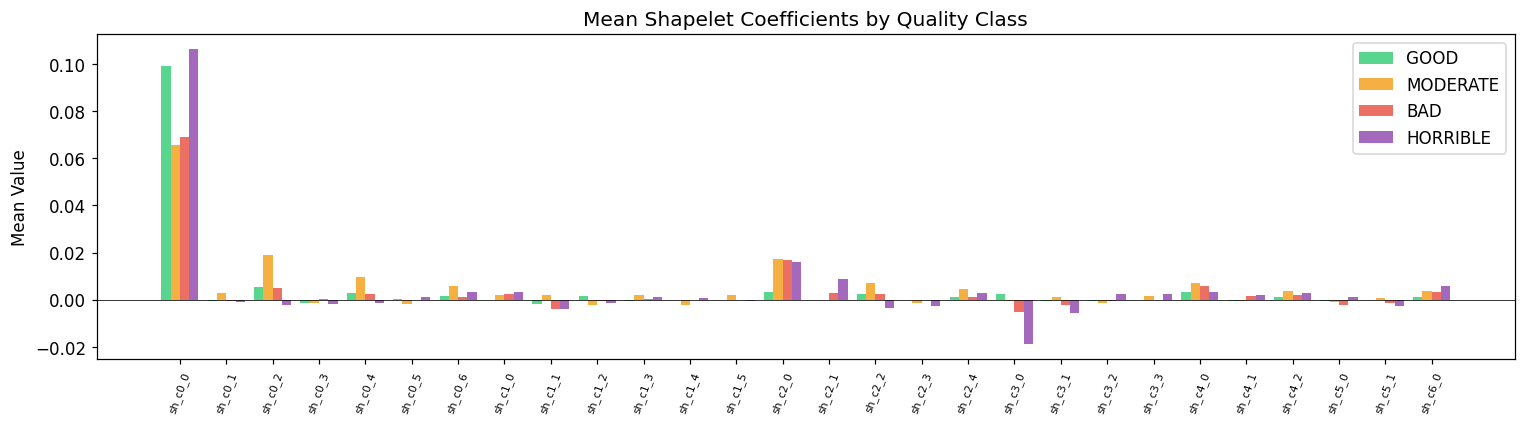

In [6]:
# Mean shapelet profile per class (spider/bar chart)
means = data.groupby('quality')[shapelet_cols].mean().reindex(QUALITY_ORDER)

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(shapelet_cols))
width = 0.2
for i, q in enumerate(QUALITY_ORDER):
    ax.bar(x + i * width, means.loc[q], width, color=QUALITY_COLORS[q],
           alpha=0.8, label=q)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(shapelet_cols, rotation=70, fontsize=7)
ax.set_ylabel('Mean Value')
ax.set_title('Mean Shapelet Coefficients by Quality Class')
ax.legend()
ax.axhline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

## 3. Dimensionality Reduction: PCA vs. Manifold Learning

Adapted from [astroML Ch. 7 — fig_S_manifold_PCA](https://www.astroml.org/book_figures/chapter7/fig_S_manifold_PCA.html).

**PCA** finds the directions of maximum global variance (linear).  
**LLE** (Locally Linear Embedding) and **IsoMap** preserve local neighbourhood structure and can unroll
nonlinear manifolds — useful if PSF quality doesn't vary linearly across the shapelet space.

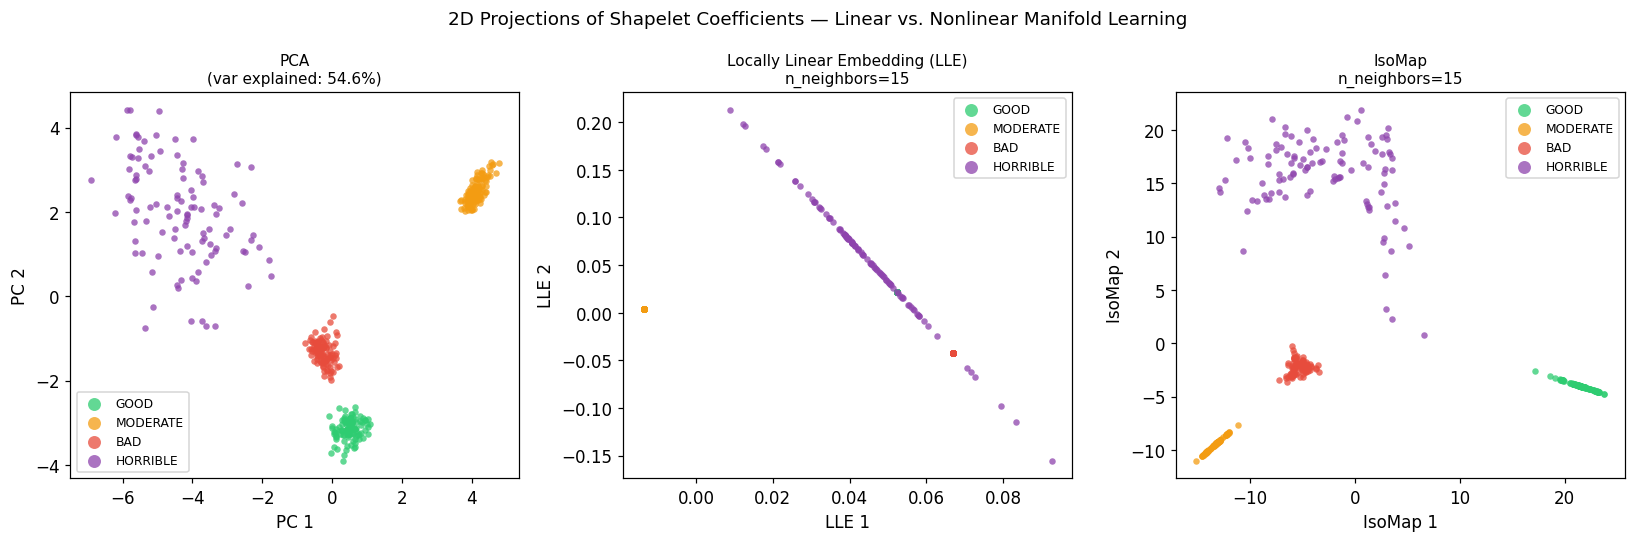

In [ ]:
# --- Fit all three projections ---
pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(X)

lle    = LocallyLinearEmbedding(n_components=2, n_neighbors=15, method='standard',
                                random_state=42)
X_lle  = lle.fit_transform(X)

iso    = Isomap(n_components=2, n_neighbors=15)
X_iso  = iso.fit_transform(X)

# --- Plot side-by-side (mirroring the astroML S-curve figure layout) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

projections = [
    (X_pca,  f'PCA\n(var explained: {pca.explained_variance_ratio_[:2].sum():.1%})', 'PC 1', 'PC 2'),
    (X_lle,  'Locally Linear Embedding (LLE)\nn_neighbors=15', 'LLE 1', 'LLE 2'),
    (X_iso,  'IsoMap\nn_neighbors=15', 'IsoMap 1', 'IsoMap 2'),
]

for ax, (X_proj, title, xlabel, ylabel) in zip(axes, projections):
    for q in QUALITY_ORDER:
        mask = y_labels == q
        ax.scatter(X_proj[mask, 0], X_proj[mask, 1],
                   c=QUALITY_COLORS[q], label=q, s=18, alpha=0.75, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(markerscale=2, fontsize=8)

plt.suptitle('2D Projections of Shapelet Coefficients — Linear vs. Nonlinear Manifold Learning',
             fontsize=12)
plt.tight_layout()
plt.show()

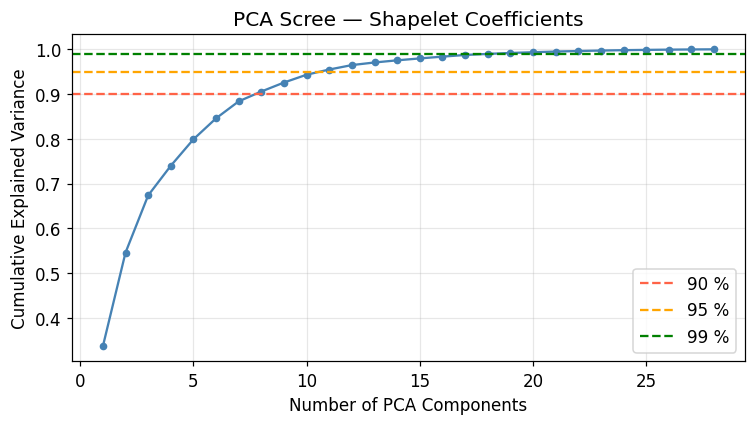

90% variance explained by 8 components
95% variance explained by 11 components
99% variance explained by 19 components


In [8]:
# PCA cumulative explained variance — how many components do we really need?
pca_full = PCA().fit(X)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, 'o-', ms=4, color='steelblue')
ax.axhline(0.90, color='tomato',  ls='--', label='90 %')
ax.axhline(0.95, color='orange',  ls='--', label='95 %')
ax.axhline(0.99, color='green',   ls='--', label='99 %')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Scree — Shapelet Coefficients')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for threshold in [0.90, 0.95, 0.99]:
    n = int(np.searchsorted(cum_var, threshold)) + 1
    print(f"{threshold:.0%} variance explained by {n} components")

## 4. SVM Classification

Adapted from [astroML Ch. 9 — fig_rrlyrae_svm](https://www.astroml.org/book_figures/chapter9/fig_rrlyrae_svm.html).

We use an **RBF-kernel SVM** (nonlinear, matching the likely nonlinear structure suggested by the
manifold projections) with `class_weight='balanced'` to handle any class imbalance.

Binary task: **GOOD** (positive) vs. **MODERATE + BAD + HORRIBLE** (negative).

In [10]:
def completeness_contamination(y_pred, y_true):
    """Completeness = recall of the positive class.
       Contamination = fraction of predicted positives that are actually negative."""
    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    completeness  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    contamination = FP / (TP + FP) if (TP + FP) > 0 else 0.0
    return completeness, contamination

In [11]:
# Full-feature SVM
clf_svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
clf_svm.fit(X_tr, yb_tr)
y_pred_svm = clf_svm.predict(X_te)

print("SVM — full shapelet feature set (GOOD vs. NOT_GOOD)")
print(classification_report(yb_te, y_pred_svm, target_names=['NOT_GOOD', 'GOOD']))

SVM — full shapelet feature set (GOOD vs. NOT_GOOD)
              precision    recall  f1-score   support

    NOT_GOOD       1.00      1.00      1.00        79
        GOOD       1.00      1.00      1.00        26

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105



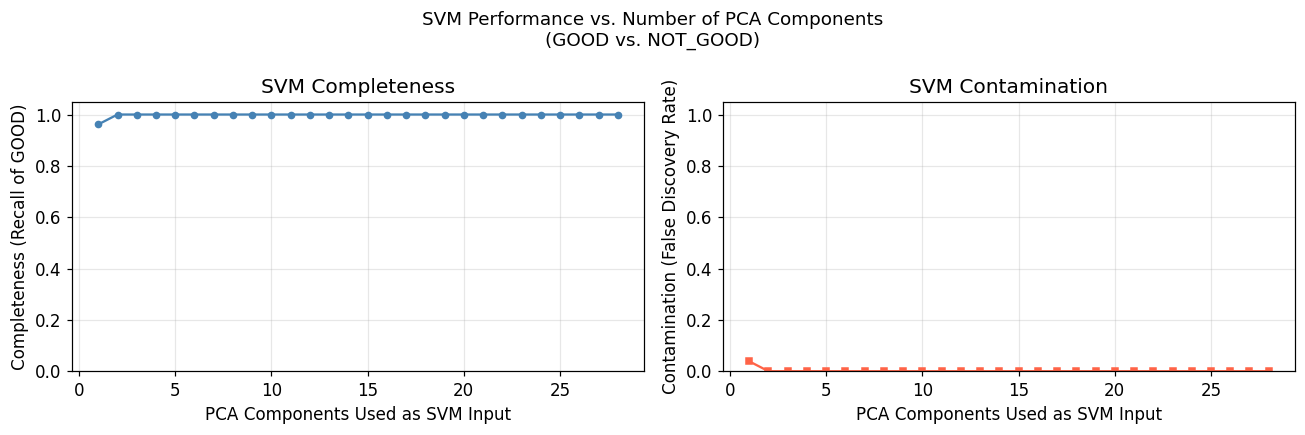

In [12]:
# Completeness & contamination as we add more PCA components as features
# (mirrors the astroML SVM example that steps through colour features)
n_comp_range = list(range(1, len(shapelet_cols) + 1))
comp_vals, cont_vals = [], []

for n in n_comp_range:
    pca_n = PCA(n_components=n)
    Xt    = pca_n.fit_transform(X_tr)
    Xv    = pca_n.transform(X_te)
    clf   = SVC(kernel='rbf', class_weight='balanced', random_state=42)
    clf.fit(Xt, yb_tr)
    c, k  = completeness_contamination(clf.predict(Xv), yb_te)
    comp_vals.append(c)
    cont_vals.append(k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(n_comp_range, comp_vals, 'o-', color='steelblue', ms=4)
axes[0].set_xlabel('PCA Components Used as SVM Input')
axes[0].set_ylabel('Completeness (Recall of GOOD)')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('SVM Completeness')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_comp_range, cont_vals, 's-', color='tomato', ms=4)
axes[1].set_xlabel('PCA Components Used as SVM Input')
axes[1].set_ylabel('Contamination (False Discovery Rate)')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('SVM Contamination')
axes[1].grid(True, alpha=0.3)

plt.suptitle('SVM Performance vs. Number of PCA Components\n(GOOD vs. NOT_GOOD)', fontsize=12)
plt.tight_layout()
plt.show()

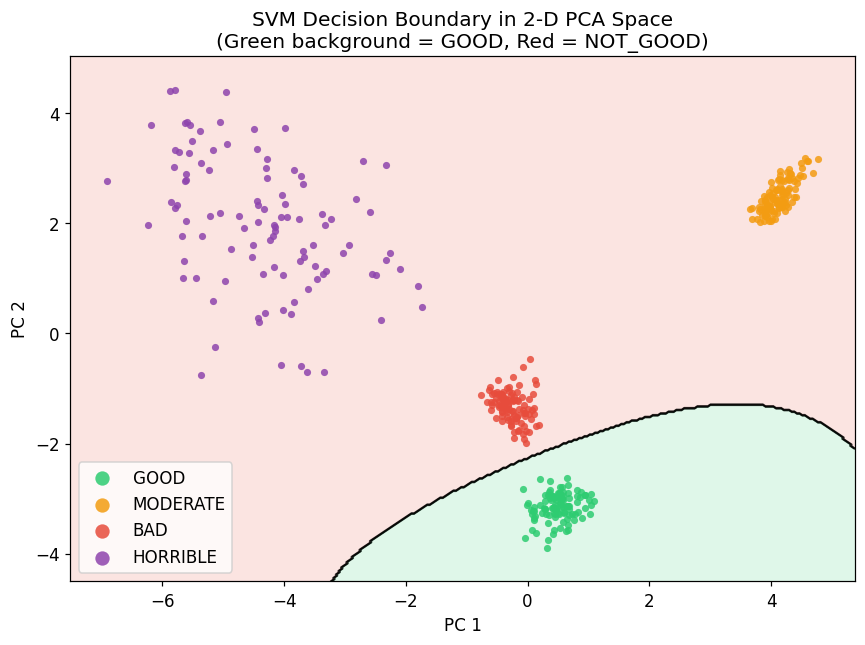

In [13]:
# Visualise the SVM decision boundary in the 2D PCA projection
X_pca_tr = X_pca[train_idx]
X_pca_te = X_pca[test_idx]

clf_2d = SVC(kernel='rbf', class_weight='balanced', random_state=42)
clf_2d.fit(X_pca_tr, yb_tr)

# Mesh grid
pad = 0.6
x0_min, x0_max = X_pca[:, 0].min() - pad, X_pca[:, 0].max() + pad
x1_min, x1_max = X_pca[:, 1].min() - pad, X_pca[:, 1].max() + pad
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 300),
                     np.linspace(x1_min, x1_max, 300))
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.15, cmap=ListedColormap(['#e74c3c', '#2ecc71']))
ax.contour(xx, yy, Z, colors='k', linewidths=0.8, alpha=0.5)

for q in QUALITY_ORDER:
    mask = y_labels == q
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=QUALITY_COLORS[q], label=q, s=22, alpha=0.85, linewidths=0)

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('SVM Decision Boundary in 2-D PCA Space\n'
             '(Green background = GOOD, Red = NOT_GOOD)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

## 5. ROC Curves & Multi-Classifier Comparison

Adapted from [astroML Ch. 9 — fig_ROC_curve](https://www.astroml.org/book_figures/chapter9/fig_ROC_curve.html).

We compare seven classifiers using:
- **ROC curves** (false-positive rate vs. true-positive rate) with AUC scores
- **Completeness vs. efficiency** plots — sweeping the decision threshold

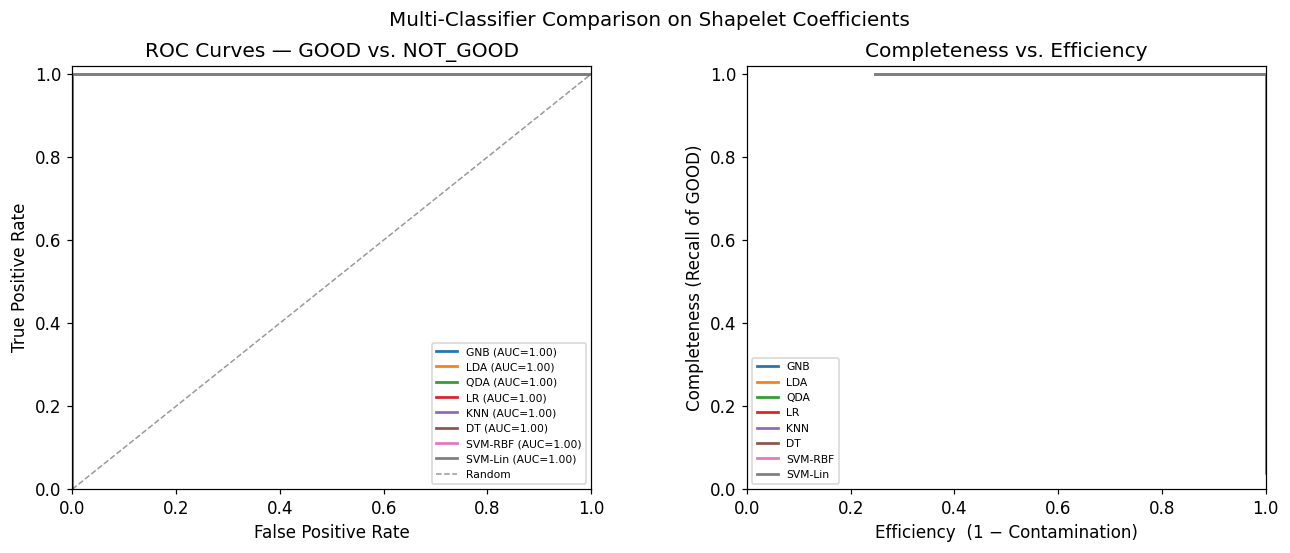

In [14]:
CLASSIFIERS = [
    (GaussianNB,                  {},                                                          'GNB'),
    (LinearDiscriminantAnalysis,  {},                                                          'LDA'),
    (QuadraticDiscriminantAnalysis, {'reg_param': 0.1},                                       'QDA'),
    (LogisticRegression,          {'class_weight': 'balanced', 'max_iter': 1000},             'LR'),
    (KNeighborsClassifier,        {'n_neighbors': 10},                                        'KNN'),
    (DecisionTreeClassifier,      {'random_state': 0, 'max_depth': 8, 'criterion': 'entropy'}, 'DT'),
    (SVC,                         {'kernel': 'rbf',    'class_weight': 'balanced',
                                   'probability': True, 'random_state': 42},                  'SVM-RBF'),
    (SVC,                         {'kernel': 'linear', 'class_weight': 'balanced',
                                   'probability': True, 'random_state': 42},                  'SVM-Lin'),
]

thresholds = np.linspace(0, 1, 201)[:-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.subplots_adjust(wspace=0.3)
ax1, ax2 = axes

for clf_class, kwargs, label in CLASSIFIERS:
    try:
        clf = clf_class(**kwargs)
        clf.fit(X_tr, yb_tr)

        if hasattr(clf, 'predict_proba'):
            y_prob = clf.predict_proba(X_te)[:, 1]
        else:
            scores = clf.decision_function(X_te)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

        # ROC
        fpr, tpr, _ = roc_curve(yb_te, y_prob)
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, lw=1.8, label=f'{label} (AUC={roc_auc:.2f})')

        # Completeness vs efficiency
        comp_arr = np.zeros(len(thresholds))
        eff_arr  = np.zeros(len(thresholds))
        for i, t in enumerate(thresholds):
            y_pred_t = (y_prob >= t).astype(int)
            c, k = completeness_contamination(y_pred_t, yb_te)
            comp_arr[i] = c
            eff_arr[i]  = 1.0 - k   # efficiency = 1 - contamination
        ax2.plot(eff_arr, comp_arr, lw=1.8, label=label)

    except Exception as e:
        print(f"{label} failed: {e}")

ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1.02)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves — GOOD vs. NOT_GOOD')
ax1.legend(fontsize=7, loc='lower right')

ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.02)
ax2.set_xlabel('Efficiency  (1 − Contamination)')
ax2.set_ylabel('Completeness (Recall of GOOD)')
ax2.set_title('Completeness vs. Efficiency')
ax2.legend(fontsize=7, loc='lower left')

plt.suptitle('Multi-Classifier Comparison on Shapelet Coefficients', fontsize=13)
plt.show()

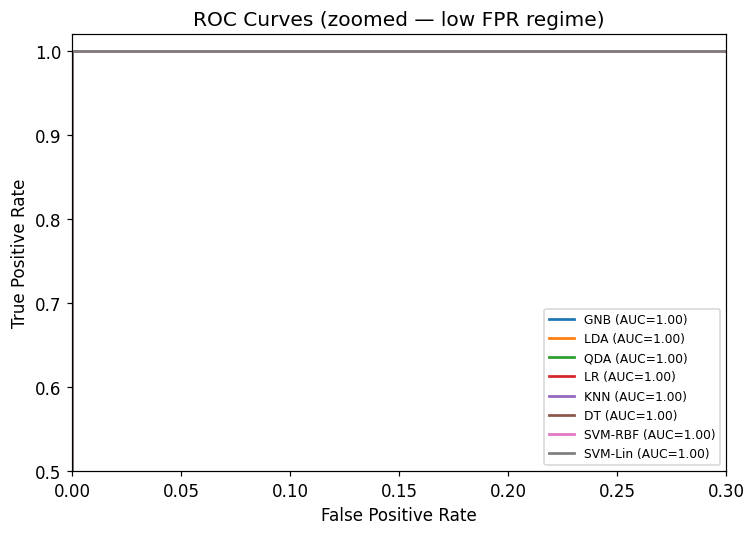

In [15]:
# Zoomed-in ROC: upper-left corner (low false-positive regime)
fig, ax = plt.subplots(figsize=(7, 5))

for clf_class, kwargs, label in CLASSIFIERS:
    try:
        clf = clf_class(**kwargs)
        clf.fit(X_tr, yb_tr)
        if hasattr(clf, 'predict_proba'):
            y_prob = clf.predict_proba(X_te)[:, 1]
        else:
            scores = clf.decision_function(X_te)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        fpr, tpr, _ = roc_curve(yb_te, y_prob)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=1.8, label=f'{label} (AUC={roc_auc:.2f})')
    except Exception:
        pass

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.set_xlim(0, 0.3); ax.set_ylim(0.5, 1.02)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (zoomed — low FPR regime)')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

## 6. Feature Importance

Which shapelet coefficients drive the classification? We use three complementary approaches:
- **Decision Tree feature importances** (Gini impurity reduction)
- **Logistic Regression coefficients** (signed — positive pushes toward GOOD)
- **PCA loadings** — which shapelet terms dominate the first two principal components

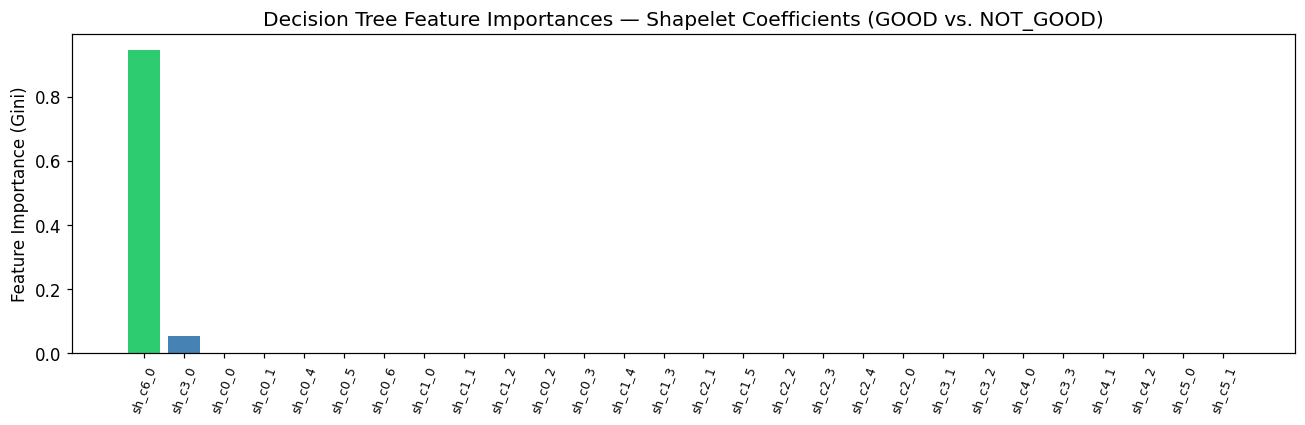

Top 5 most important shapelet features:
sh_c6_0    0.947141
sh_c3_0    0.052859
sh_c0_0    0.000000
sh_c0_1    0.000000
sh_c0_4    0.000000
dtype: float64


In [16]:
# Decision Tree feature importances
dt = DecisionTreeClassifier(random_state=0, max_depth=8, criterion='entropy')
dt.fit(X_tr, yb_tr)
importances = pd.Series(dt.feature_importances_, index=shapelet_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#2ecc71' if importances[c] == importances.max() else 'steelblue' for c in importances.index]
ax.bar(importances.index, importances.values, color=colors)
ax.set_xticklabels(importances.index, rotation=70, fontsize=8)
ax.set_ylabel('Feature Importance (Gini)')
ax.set_title('Decision Tree Feature Importances — Shapelet Coefficients (GOOD vs. NOT_GOOD)')
plt.tight_layout()
plt.show()

print("Top 5 most important shapelet features:")
print(importances.head())

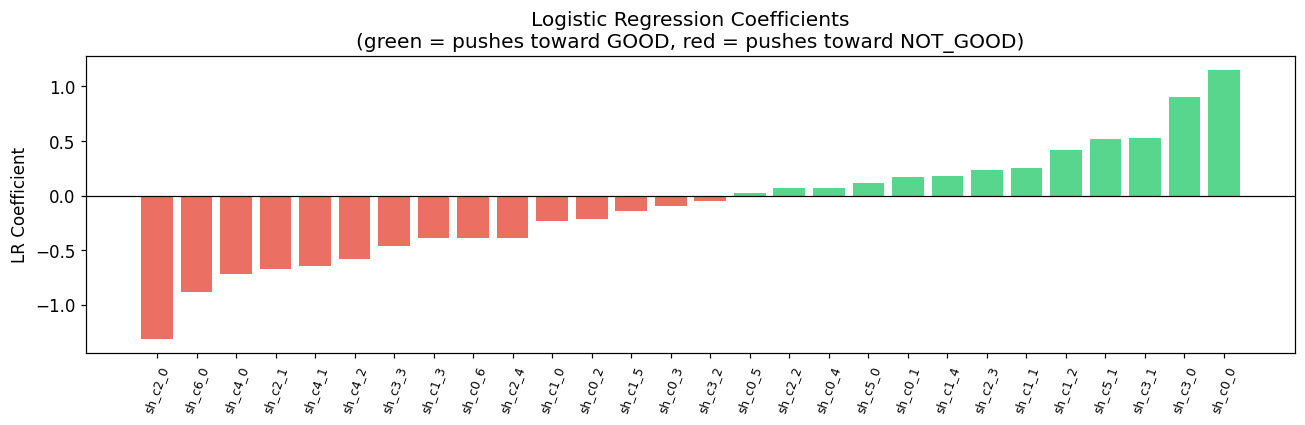

In [17]:
# Logistic Regression coefficients (signed importance)
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_tr, yb_tr)
coefs = pd.Series(lr.coef_[0], index=shapelet_cols).sort_values()

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in coefs.values]
ax.bar(coefs.index, coefs.values, color=colors, alpha=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticklabels(coefs.index, rotation=70, fontsize=8)
ax.set_ylabel('LR Coefficient')
ax.set_title('Logistic Regression Coefficients\n'
             '(green = pushes toward GOOD, red = pushes toward NOT_GOOD)')
plt.tight_layout()
plt.show()

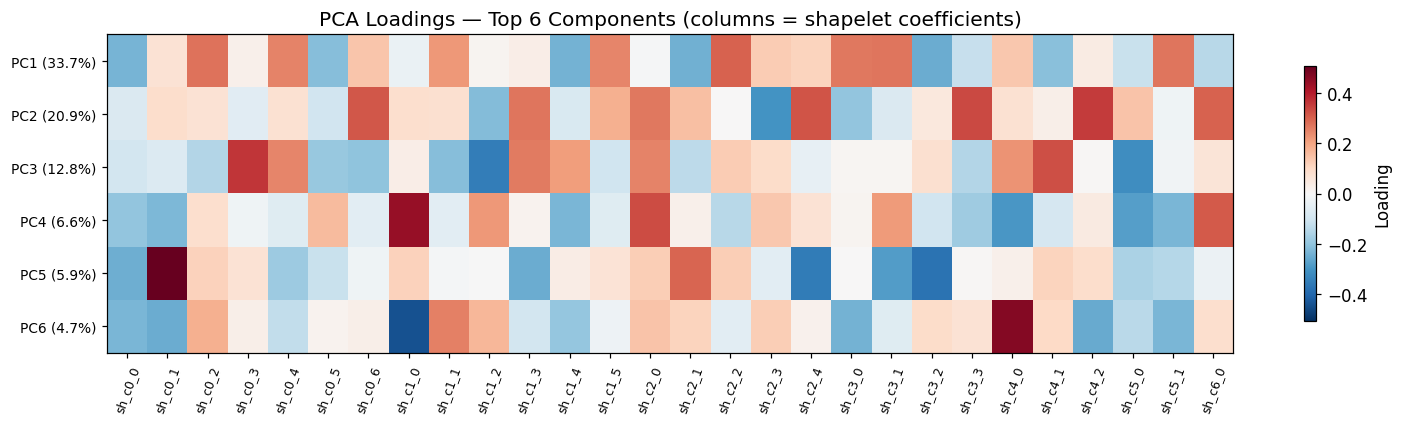

In [18]:
# PCA loadings heatmap — what shapelet terms each PC captures
pca6 = PCA(n_components=6).fit(X)
loadings = pd.DataFrame(
    pca6.components_,
    index=[f'PC{i+1} ({v:.1%})' for i, v in enumerate(pca6.explained_variance_ratio_)],
    columns=shapelet_cols
)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(loadings.values, aspect='auto', cmap='RdBu_r',
               vmin=-loadings.values.max(), vmax=loadings.values.max())
ax.set_yticks(range(len(loadings)))
ax.set_yticklabels(loadings.index, fontsize=9)
ax.set_xticks(range(len(shapelet_cols)))
ax.set_xticklabels(shapelet_cols, rotation=70, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8, label='Loading')
ax.set_title('PCA Loadings — Top 6 Components (columns = shapelet coefficients)')
plt.tight_layout()
plt.show()

In [19]:
# Summary table: mean absolute value difference between GOOD and NOT_GOOD per coefficient
good_mask    = y_labels == 'GOOD'
not_good_mask = ~good_mask

diff = pd.Series(
    np.abs(X_raw[good_mask].mean(axis=0) - X_raw[not_good_mask].mean(axis=0)),
    index=shapelet_cols
).sort_values(ascending=False)

print("Shapelet coefficients ranked by |mean(GOOD) − mean(NOT_GOOD)|")
print(diff.to_string())

Shapelet coefficients ranked by |mean(GOOD) − mean(NOT_GOOD)|
sh_c0_0    0.018624
sh_c2_0    0.013350
sh_c3_0    0.010473
sh_c2_1    0.004057
sh_c6_0    0.003058
sh_c1_2    0.002908
sh_c1_0    0.002784
sh_c4_0    0.002206
sh_c0_6    0.002041
sh_c3_1    0.001838
sh_c0_2    0.001775
sh_c4_2    0.001707
sh_c2_4    0.001595
sh_c1_3    0.001593
sh_c3_3    0.001443
sh_c2_3    0.001366
sh_c4_1    0.001321
sh_c5_1    0.000929
sh_c0_1    0.000876
sh_c0_4    0.000811
sh_c0_5    0.000613
sh_c1_5    0.000538
sh_c3_2    0.000496
sh_c0_3    0.000474
sh_c1_4    0.000361
sh_c2_2    0.000340
sh_c1_1    0.000262
sh_c5_0    0.000015
